In [18]:
%pip install -q datasets pyttsx3 seaborn tensorflow scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import string
import time
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, Activation, Add,
    GlobalAveragePooling2D, Input
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('TensorFlow version:', tf.__version__)
print('All imports successful.')


Note: you may need to restart the kernel to use updated packages.
TensorFlow version: 2.20.0
All imports successful.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\raviv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [19]:
# -----------------------------
# 1. Load Dataset
# -----------------------------
train_df = pd.read_csv("data/sign_mnist_train.csv")
test_df = pd.read_csv("data/sign_mnist_test.csv")

X_train_raw = train_df.drop("label", axis=1)
y_train_raw = train_df["label"]

X_test_raw = test_df.drop("label", axis=1)
y_test_raw = test_df["label"]

print(f'Training samples : {len(train_df):,}')
print(f'Test samples     : {len(test_df):,}')
print(f'Feature columns  : {X_train_raw.shape[1]}')
print(f'Classes          : {sorted(y_train_raw.unique())}')


Training samples : 27,455
Test samples     : 7,172
Feature columns  : 784
Classes          : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


EXPLOTARY DATA ANALYSIS

In [20]:
# -----------------------------
# 2. Basic Dataset Information
# -----------------------------
print("\nDataset Info:")
print(train_df.info())

print("\nMissing Values Check:")
print(train_df.isnull().sum().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB
None

Missing Values Check:
0


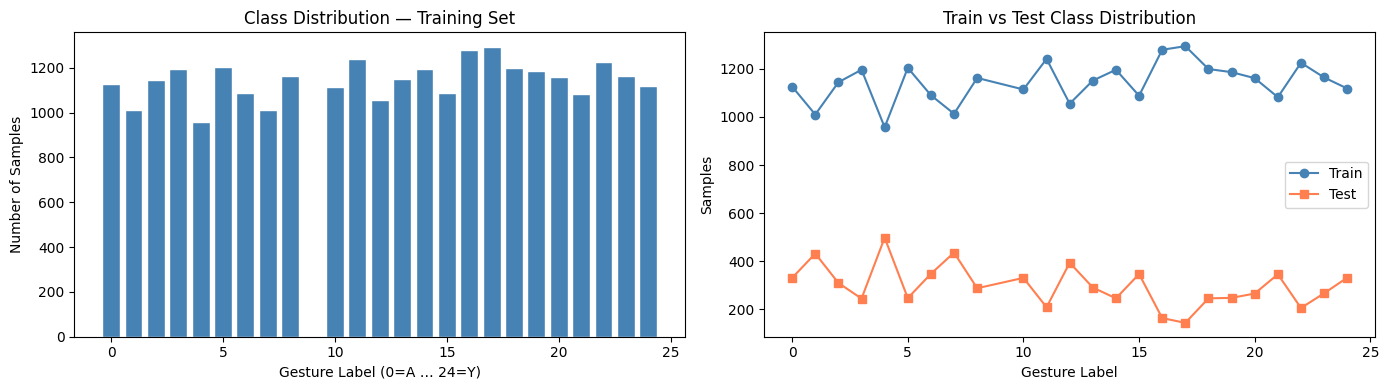

Min class count: 957  |  Max: 1294  |  Range: 337


In [21]:
# -----------------------------
# 3.2 Class Distribution
# -----------------------------
label_counts = train_df['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(label_counts.index, label_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Class Distribution — Training Set')
axes[0].set_xlabel('Gesture Label (0=A … 24=Y)')
axes[0].set_ylabel('Number of Samples')

train_counts = train_df['label'].value_counts().sort_index()
test_counts  = test_df['label'].value_counts().sort_index()
axes[1].plot(train_counts.index, train_counts.values, marker='o', label='Train', color='steelblue')
axes[1].plot(test_counts.index,  test_counts.values,  marker='s', label='Test',  color='coral')
axes[1].set_title('Train vs Test Class Distribution')
axes[1].set_xlabel('Gesture Label')
axes[1].set_ylabel('Samples')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Min class count: {label_counts.min()}  |  Max: {label_counts.max()}  |  Range: {label_counts.max()-label_counts.min()}')

The figure shows that all gesture classes contain approximately 1,000 to 1,300 samples, indicating a relatively balanced dataset. No significant class imbalance is observed, as sample counts across labels remain consistent.

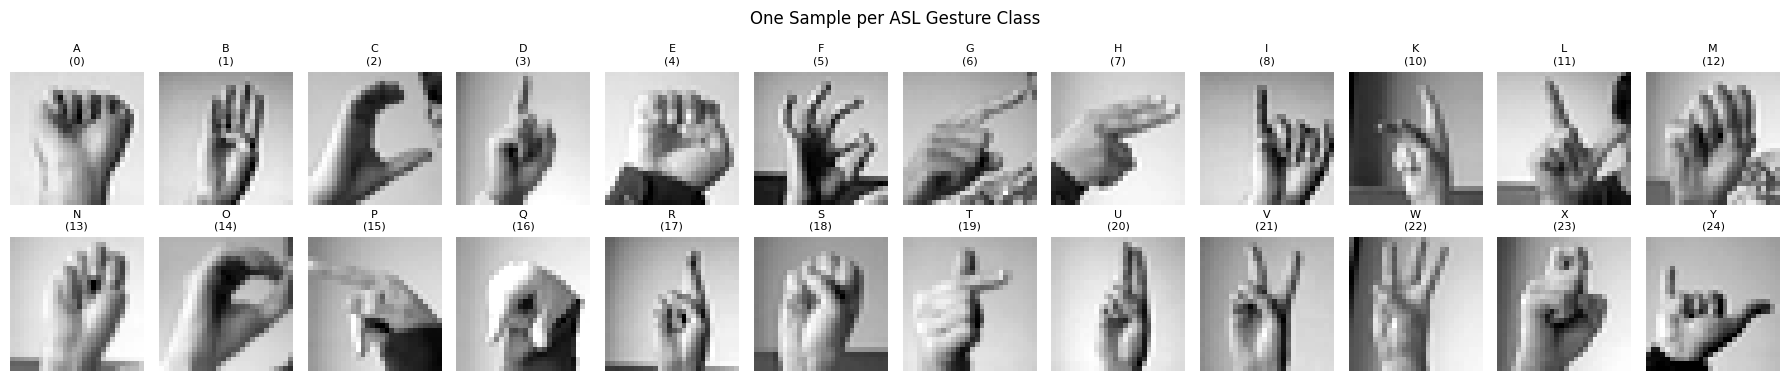

In [22]:
# -----------------------------
# 3.3 Sample Image Visualisation
# -----------------------------
letters = list(string.ascii_uppercase)
letters.remove('J')
letters.remove('Z')

fig, axes = plt.subplots(2, 12, figsize=(18, 4))
axes = axes.flatten()
for idx, label_val in enumerate(sorted(train_df['label'].unique())):
    sample = train_df[train_df['label'] == label_val].iloc[0]
    img = sample.drop('label').values.reshape(28, 28)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'{letters[idx]}\n({label_val})', fontsize=8)
    axes[idx].axis('off')
plt.suptitle('One Sample per ASL Gesture Class', fontsize=12)
plt.tight_layout()
plt.show()

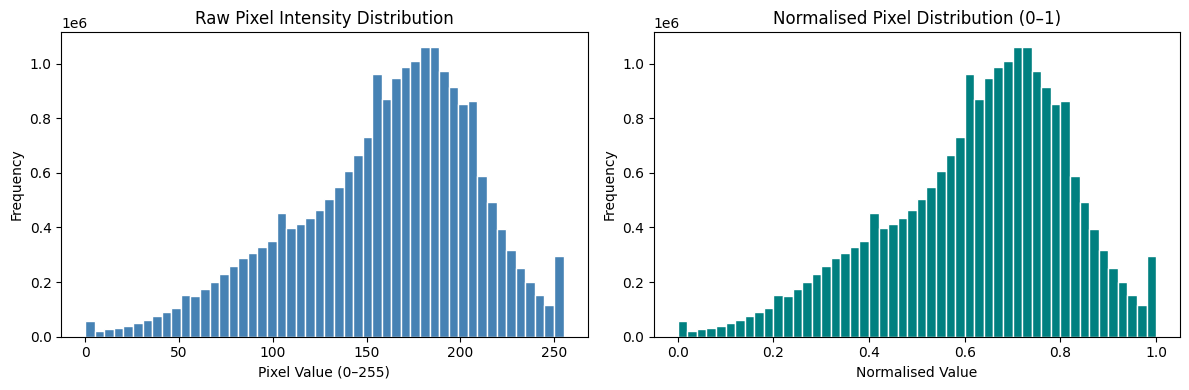

Mean: 159.29  |  Std: 48.77  |  Min: 0  |  Max: 255


In [23]:
# -----------------------------
# 3.4 Pixel Intensity Analysis
# -----------------------------
pixels = X_train_raw.values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pixels, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Pixel Intensity Distribution')
axes[0].set_xlabel('Pixel Value (0–255)')
axes[0].set_ylabel('Frequency')

norm_pixels = pixels / 255.0
axes[1].hist(norm_pixels, bins=50, color='teal', edgecolor='white')
axes[1].set_title('Normalised Pixel Distribution (0–1)')
axes[1].set_xlabel('Normalised Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'Mean: {np.mean(pixels):.2f}  |  Std: {np.std(pixels):.2f}  |  Min: {np.min(pixels)}  |  Max: {np.max(pixels)}')

This plot illustrates the distribution of grayscale pixel intensities across the ASL-MNIST training dataset. Pixel values range from 0 (black) to 255 (white), representing different brightness levels within the images.

The histogram indicates that most pixel values are concentrated between approximately 100 and 200, with a peak around 160–180. This suggests that a large portion of the image content corresponds to mid-to-high intensity values, which primarily represent the hand regions. Lower pixel values correspond to darker background areas.

Very few pixels are observed at extreme intensity levels, indicating the absence of overexposed or underexposed images. The smooth distribution demonstrates consistent lighting conditions and good dataset quality.

This analysis confirms sufficient contrast between foreground and background regions, which is beneficial for feature extraction. Furthermore, it justifies the application of pixel normalization prior to model training to improve numerical stability and learning efficiency.

In [25]:
# -----------------------------
# 6. Image Dimension Verification
# -----------------------------
image_shape = X_train_raw.iloc[0].values.reshape(28, 28).shape
print("\nImage Shape:", image_shape)



Image Shape: (28, 28)


To confirm the consistency of image dimensions within the dataset, a sample image was reshaped from its flattened representation into a two-dimensional format. The resulting shape was verified as 28 × 28 pixels.

This verification step ensures that all images conform to the expected input size required for convolutional neural networks. Uniform image dimensions are essential for batch processing and model training, as inconsistent shapes can lead to computational errors and degraded performance.

The confirmed image size aligns with the ASL-MNIST dataset specifications and supports the suitability of the dataset for CNN-based gesture recognition.

The class-wise statistical analysis confirms distinct pixel intensity patterns across gestures and demonstrates adequate variability without excessive noise, providing a reliable foundation for deep learning model training.

PREPROCESSING

In [32]:
# -----------------------------
# 4.1 Label Encoding
# -----------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_raw)   # integers 0–23
y_test_enc  = le.transform(y_test_raw)

# One-hot encode for deep learning models
y_train_cat = to_categorical(y_train_enc)     # shape (N, 24)
y_test_cat  = to_categorical(y_test_enc)

print(f'Encoded label range : {y_train_enc.min()} – {y_train_enc.max()}')
print(f'One-hot shape       : {y_train_cat.shape}')

Encoded label range : 0 – 23
One-hot shape       : (27455, 24)


In [33]:
# -----------------------------
# 4.2 Reshape & Normalise for CNN models (28x28x1, range 0–1)
# -----------------------------
X_train = X_train_raw.values.reshape(-1, 28, 28, 1) / 255.0
X_test  = X_test_raw.values.reshape(-1, 28, 28, 1)  / 255.0

# Flat version for sklearn baseline models
X_train_flat = X_train_raw.values / 255.0    # shape (27455, 784)
X_test_flat  = X_test_raw.values  / 255.0

print(f'CNN input shape     : {X_train.shape}')
print(f'Flat input shape    : {X_train_flat.shape}')

CNN input shape     : (27455, 28, 28, 1)
Flat input shape    : (27455, 784)


In [34]:
# -----------------------------
# 4.3 Preprocess for EfficientNetB0 (64x64x3, range 0–255)
# -----------------------------
def preprocess_for_efficientnet(X, img_size=64):
    X_resized = tf.image.resize(X, [img_size, img_size])   # (N, 64, 64, 1)
    X_rgb     = tf.repeat(X_resized, 3, axis=-1)           # (N, 64, 64, 3)
    return (X_rgb * 255.0).numpy()                         # back to 0–255

print('Preparing EfficientNetB0 inputs...')
X_train_eff = preprocess_for_efficientnet(X_train)
X_test_eff  = preprocess_for_efficientnet(X_test)
print(f'EfficientNet input shape: {X_train_eff.shape}')

Preparing EfficientNetB0 inputs...
EfficientNet input shape: (27455, 64, 64, 3)


In [35]:
# -----------------------------
# 4.4 Data Augmentation Generator (used by CNN, ResNet, EfficientNet)
# Note: horizontal_flip=False — flipping changes ASL hand meaning
# -----------------------------
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    validation_split=0.1
)

def make_generators(X, y, batch_size=64):
    train_gen = datagen.flow(X, y, batch_size=batch_size, subset='training',   seed=42)
    val_gen   = datagen.flow(X, y, batch_size=batch_size, subset='validation', seed=42)
    return train_gen, val_gen

print('Augmentation generator ready.')

Augmentation generator ready.


5.Baseline Models - Random Forest and SVM

In [36]:
# -----------------------------
# 5.1 Random Forest
# -----------------------------
print('Training Random Forest (n_estimators=200)...')
t0 = time.time()

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_flat, y_train_enc)

rf_time = time.time() - t0
rf_preds = rf.predict(X_test_flat)
rf_acc   = accuracy_score(y_test_enc, rf_preds)

print(f'Random Forest Accuracy : {rf_acc:.4f} ({rf_acc*100:.2f}%)')
print(f'Training time          : {rf_time:.1f}s')
print('\nClassification Report:')
print(classification_report(y_test_enc, rf_preds, target_names=letters))

Training Random Forest (n_estimators=200)...
Random Forest Accuracy : 0.8211 (82.11%)
Training time          : 14.2s

Classification Report:
              precision    recall  f1-score   support

           A       0.93      1.00      0.96       331
           B       0.98      0.94      0.96       432
           C       0.96      1.00      0.98       310
           D       0.89      0.99      0.94       245
           E       0.90      0.99      0.94       498
           F       0.94      0.91      0.93       247
           G       0.93      0.86      0.89       348
           H       0.99      0.94      0.97       436
           I       0.83      0.80      0.82       288
           K       0.73      0.65      0.69       331
           L       0.82      1.00      0.90       209
           M       0.84      0.69      0.76       394
           N       0.82      0.54      0.65       291
           O       1.00      0.92      0.96       246
           P       0.93      1.00      0.97     

The labels were first converted into numerical format using LabelEncoder to make them compatible with machine learning algorithms. The images were reshaped into 28×28 grayscale format to match CNN input requirements. Pixel normalization was applied to scale values between 0 and 1 to improve convergence. Finally, one-hot encoding was used to convert class labels into categorical vectors suitable for softmax classification. If you do not one-hot encode:
    Shape mismatch error
    Incorrect loss calculation

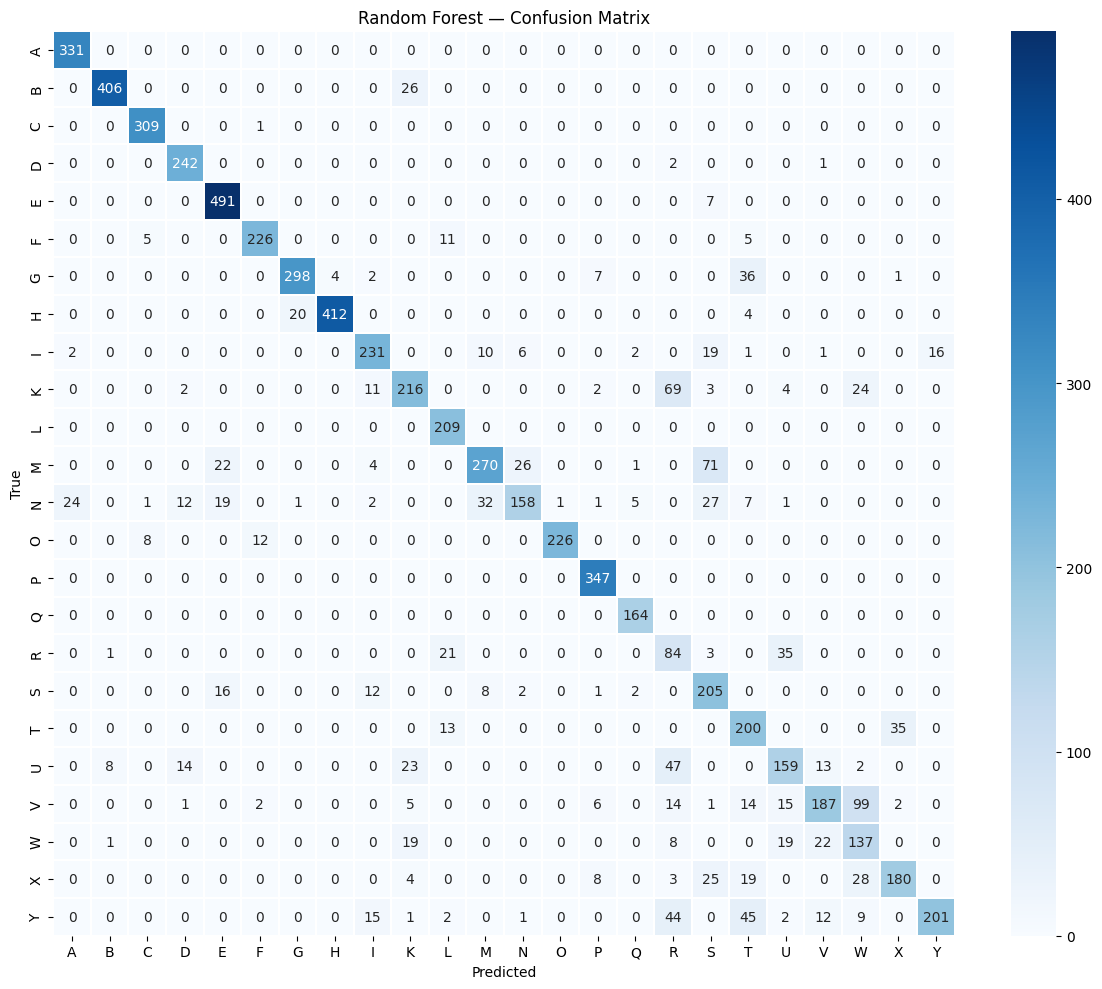

In [37]:
# Confusion Matrix — Random Forest
cm_rf = confusion_matrix(y_test_enc, rf_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_rf, annot=True, fmt='d', linewidth=0.2,
            xticklabels=letters, yticklabels=letters, cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [38]:
# -----------------------------
# 5.2 Support Vector Machine (RBF kernel)
# -----------------------------
print('Training SVM (RBF kernel, C=10)...')
t0 = time.time()

svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_flat, y_train_enc)

svm_time  = time.time() - t0
svm_preds = svm.predict(X_test_flat)
svm_acc   = accuracy_score(y_test_enc, svm_preds)

print(f'SVM Accuracy    : {svm_acc:.4f} ({svm_acc*100:.2f}%)')
print(f'Training time   : {svm_time:.1f}s')
print('\nClassification Report:')
print(classification_report(y_test_enc, svm_preds, target_names=letters))

Training SVM (RBF kernel, C=10)...
SVM Accuracy    : 0.8371 (83.71%)
Training time   : 89.5s

Classification Report:
              precision    recall  f1-score   support

           A       0.90      1.00      0.95       331
           B       1.00      0.99      1.00       432
           C       0.85      0.99      0.92       310
           D       0.94      1.00      0.97       245
           E       0.95      1.00      0.97       498
           F       0.71      0.83      0.77       247
           G       0.93      0.93      0.93       348
           H       0.99      0.93      0.96       436
           I       0.80      0.87      0.83       288
           K       0.75      0.54      0.63       331
           L       0.90      0.96      0.93       209
           M       0.84      0.74      0.78       394
           N       0.90      0.66      0.76       291
           O       1.00      0.83      0.90       246
           P       1.00      1.00      1.00       347
           Q      

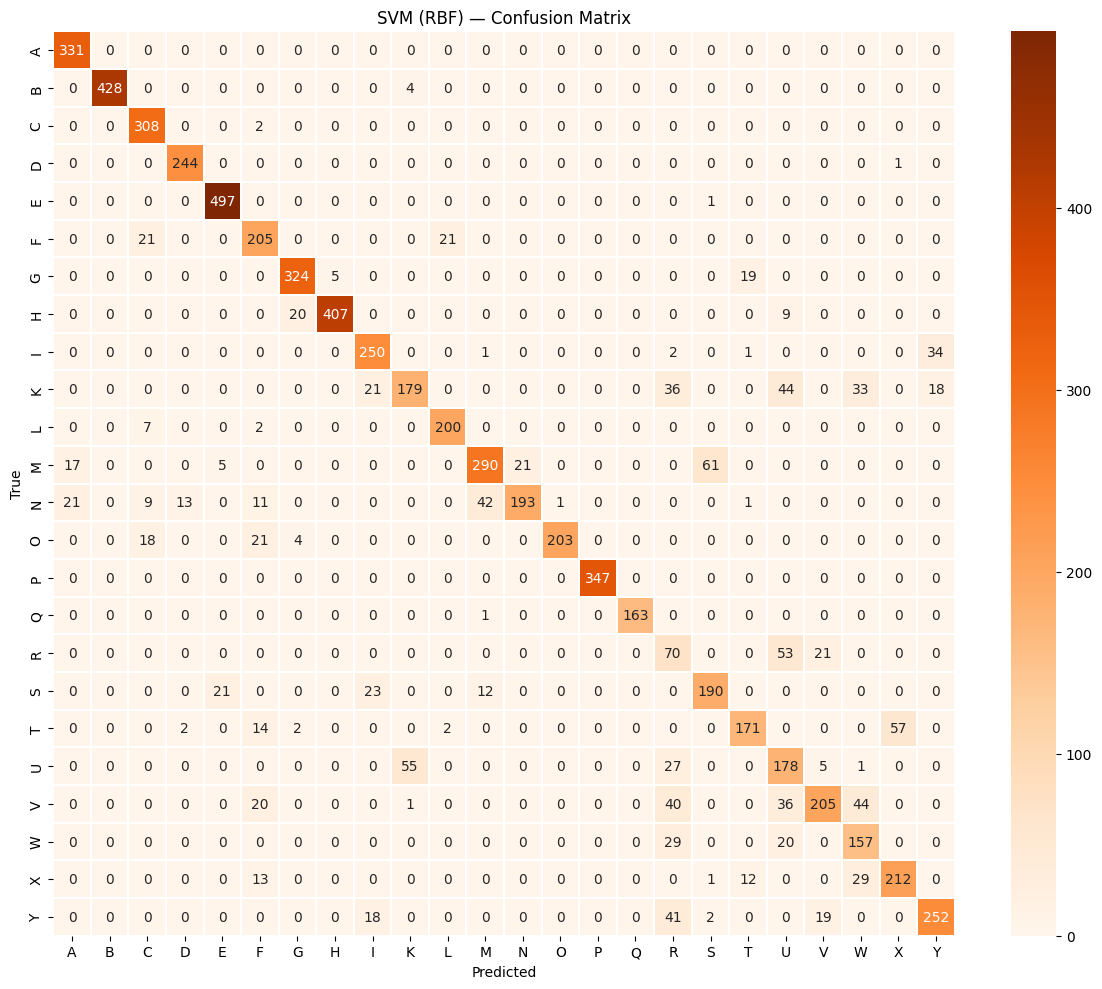

In [39]:
# Confusion Matrix — SVM
cm_svm = confusion_matrix(y_test_enc, svm_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_svm, annot=True, fmt='d', linewidth=0.2,
            xticklabels=letters, yticklabels=letters, cmap='Oranges')
plt.title('SVM (RBF) — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

6.Custom CNN with Hyperparameter Grid Search

In [40]:
# -----------------------------
# 6.1 Model Definition
# -----------------------------
def create_cnn(dropout_rate=0.5):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D(),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(24, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

create_cnn().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,840 (886.09 KB)

 Trainable params: 226,840 (886.09 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# -----------------------------
# 6.2 Hyperparameter Grid Search
# -----------------------------
batch_sizes   = [32, 64]
epochs_list   = [10, 15]
dropouts      = [0.3, 0.5]

cnn_results   = []
best_cnn_acc  = 0
best_cnn_model = None
best_cnn_history = None

for batch in batch_sizes:
    for epochs in epochs_list:
        for dropout in dropouts:
            print(f'  batch={batch}, epochs={epochs}, dropout={dropout}', end=' ... ')
            model = create_cnn(dropout)
            history = model.fit(
                X_train, y_train_cat,
                epochs=epochs,
                batch_size=batch,
                validation_split=0.1,
                verbose=0
            )
            _, acc = model.evaluate(X_test, y_test_cat, verbose=0)
            cnn_results.append({'batch': batch, 'epochs': epochs, 'dropout': dropout, 'accuracy': acc})
            print(f'acc={acc:.4f}')
            if acc > best_cnn_acc:
                best_cnn_acc     = acc
                best_cnn_model   = model
                best_cnn_history = history

cnn_df = pd.DataFrame(cnn_results).sort_values('accuracy', ascending=False)
print('\nGrid Search Results:')
print(cnn_df.to_string(index=False))
print(f'\nBest CNN Accuracy: {best_cnn_acc:.4f}')



  batch=32, epochs=10, dropout=0.3 ... acc=0.9060
  batch=32, epochs=10, dropout=0.5 ... acc=0.9368
  batch=32, epochs=15, dropout=0.3 ... acc=0.9282
  batch=32, epochs=15, dropout=0.5 ... acc=0.9381
  batch=64, epochs=10, dropout=0.3 ... acc=0.9359
  batch=64, epochs=10, dropout=0.5 ... acc=0.9290
  batch=64, epochs=15, dropout=0.3 ... acc=0.9233
  batch=64, epochs=15, dropout=0.5 ... acc=0.9431

Grid Search Results:
 batch  epochs  dropout  accuracy
    64      15      0.5  0.943112
    32      15      0.5  0.938093
    32      10      0.5  0.936838
    64      10      0.3  0.935862
    64      10      0.5  0.929030
    32      15      0.3  0.928193
    64      15      0.3  0.923313
    32      10      0.3  0.906023

Best CNN Accuracy: 0.9431


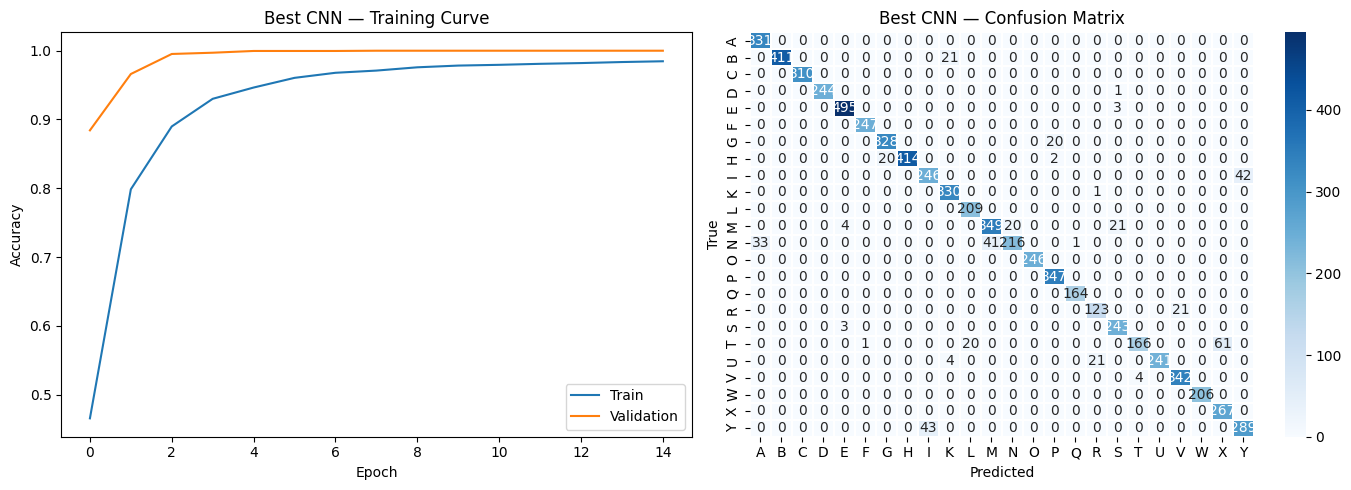


Classification Report (Best CNN):
              precision    recall  f1-score   support

           A       0.91      1.00      0.95       331
           B       1.00      0.95      0.98       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       0.99      0.99      0.99       498
           F       1.00      1.00      1.00       247
           G       0.94      0.94      0.94       348
           H       1.00      0.95      0.97       436
           I       0.85      0.85      0.85       288
           K       0.93      1.00      0.96       331
           L       0.91      1.00      0.95       209
           M       0.89      0.89      0.89       394
           N       0.92      0.74      0.82       291
           O       1.00      1.00      1.00       246
           P       0.94      1.00      0.97       347
           Q       0.99      1.00      1.00       164
           R       0.85      0.85      0.85   

In [42]:
# -----------------------------
# 6.3 Best CNN — Evaluation
# -----------------------------
cnn_preds = np.argmax(best_cnn_model.predict(X_test, verbose=0), axis=1)
y_true    = np.argmax(y_test_cat, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training curve
axes[0].plot(best_cnn_history.history['accuracy'],     label='Train')
axes[0].plot(best_cnn_history.history['val_accuracy'], label='Validation')
axes[0].set_title('Best CNN — Training Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Confusion matrix
cm_cnn = confusion_matrix(y_true, cnn_preds)
sns.heatmap(cm_cnn, ax=axes[1], annot=True, fmt='d', linewidth=0.2,
            xticklabels=letters, yticklabels=letters, cmap='Blues')
axes[1].set_title('Best CNN — Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

print('\nClassification Report (Best CNN):')
print(classification_report(y_true, cnn_preds, target_names=letters))

Convolutional Neural Network (CNN) built using a Sequential architecture, where layers are stacked one after another. It begins with two convolutional layers (32 and 64 filters of size 3×3) with ReLU activation to automatically extract important visual features from 28×28 grayscale hand gesture images. Each convolution layer is followed by MaxPooling to reduce spatial dimensions and computational complexity while retaining key features. The extracted feature maps are then flattened into a one-dimensional vector and passed to a fully connected Dense layer with 128 neurons to learn high-level patterns. A Dropout layer (50%) is used to prevent overfitting by randomly disabling neurons during training. Finally, a Dense output layer with 24 neurons and softmax activation produces probability scores for each ASL alphabet class, enabling multi-class gesture classification.

The model has 226,840 total trainable parameters, meaning all weights are updated during training. Most parameters (204,928) are in the fully connected Dense layer, which typically contains the largest number of learnable weights. There are no non-trainable parameters, indicating the entire network participates in learning.

Overall, this is a well-structured CNN suitable for ASL gesture classification.

7. ResNet - style Model with Skip Connections

In [43]:
# -----------------------------
# 7.1 Residual Block Definition
# -----------------------------

def residual_block(x, filters, stride=1,downsample=False):
    shortcut = x
    

    x = Conv2D(filters, (3, 3), strides=stride, padding='same',use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, (3, 3),strides=1, padding='same',use_bias=False)(x)
    x = BatchNormalization()(x)

    if downsample or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), strides=stride, padding='same',use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([shortcut, x])
    x = Activation('relu')(x)
    return x

In [44]:
# -----------------------------
# 7.2 ResNet-18 Architecture
# -----------------------------

def build_resnet(input_shape=(28, 28, 1), num_classes=24):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((3, 3), strides=2, padding='same')(x)

    # Layer 1 -32 layers
    x = residual_block(x, 32)
    x = residual_block(x, 32)

    # Layer 2 - 64 layers
    x = residual_block(x, 64, stride=2, downsample=True)
    x = residual_block(x, 64)

    # Layer 3 -128 layers
    x = residual_block(x, 128, stride=2, downsample=True)
    x = residual_block(x, 128)


    x = GlobalAveragePooling2D()(x)
    x = Dense(256,activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model
resnet_model = build_resnet()
resnet_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 28, 28,    │        288 │ input_layer_11[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 14, 14,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 14, 14,    │      9,216 │ max_pooling2d_18… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 14, 14,    │      9,216 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 14, 14,    │          0 │ max_pooling2d_18… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 14, 14,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 14, 14,    │      9,216 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 14, 14,    │      9,216 │ activation_3[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_22[0][0] 

 Total params: 736,184 (2.81 MB)

 Trainable params: 733,944 (2.80 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [45]:
# -----------------------------
# 7.3 Phase 1: Train ResNet
# -----------------------------

callbacks_resnet = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,min_lr=1e-6, verbose=1 )]
train_gen_r, val_gen_r = make_generators(X_train, y_train_cat, batch_size=64)
print('Phase: 1 Training ResNet-18 from scratch...')

t0 = time.time()
history_resnet= resnet_model.fit(
    train_gen_r,
    validation_data=val_gen_r,
    epochs=40,
    callbacks=callbacks_resnet,
    verbose=1
)
resnet_time = time.time() - t0
_, resnet_acc = resnet_model.evaluate(X_test, y_test_cat, verbose=0)
print(f'\nResNet Accuracy : {resnet_acc:.4f} ({resnet_acc*100:.2f}%)')
print(f'Training time   : {resnet_time/60:.1f} min')

Phase: 1 Training ResNet-18 from scratch...
Epoch 1/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 33s 72ms/step - accuracy: 0.7163 - loss: 0.8668 - val_accuracy: 0.1945 - val_loss: 4.4525 - learning_rate: 0.0010
Epoch 2/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 31s 81ms/step - accuracy: 0.9590 - loss: 0.1291 - val_accuracy: 0.9060 - val_loss: 0.3537 - learning_rate: 0.0010
Epoch 3/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.9736 - loss: 0.0833 - val_accuracy: 0.8171 - val_loss: 0.6790 - learning_rate: 0.0010
Epoch 4/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - accuracy: 0.9815 - loss: 0.0612 - val_accuracy: 0.9053 - val_loss: 0.3269 - learning_rate: 0.0010
Epoch 5/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - accuracy: 0.9883 - loss: 0.0381 - val_accuracy: 0.8383 - val_loss: 0.7034 - learning_rate: 0.0010
Epoch 6/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 245s 633ms/step - accuracy: 0.9873 - loss: 0.0408 - val_accuracy: 0.9483 - val_loss: 0.1830 - learning_rate: 0.0010
Epoch 7/40
387/387 ━━━━━━━━━━━

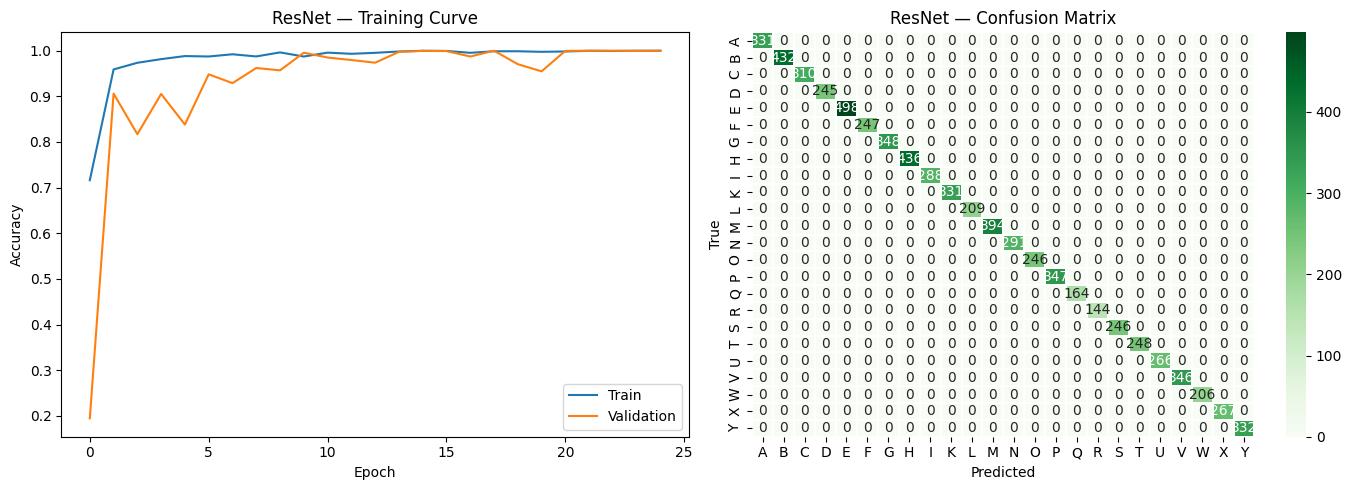


Classification Report (ResNet):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      1.00      1.00       498
           F       1.00      1.00      1.00       247
           G       1.00      1.00      1.00       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       1.00      1.00      1.00       331
           L       1.00      1.00      1.00       209
           M       1.00      1.00      1.00       394
           N       1.00      1.00      1.00       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       1.00      1.00      1.00     

In [46]:
# -----------------------------
# 7.4 ResNet — Evaluation
# -----------------------------
resnet_preds = np.argmax(resnet_model.predict(X_test, verbose=0), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_resnet.history['accuracy'],     label='Train')
axes[0].plot(history_resnet.history['val_accuracy'], label='Validation')
axes[0].set_title('ResNet — Training Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

cm_resnet = confusion_matrix(y_true, resnet_preds)
sns.heatmap(cm_resnet, ax=axes[1], annot=True, fmt='d', linewidth=0.2,
            xticklabels=letters, yticklabels=letters, cmap='Greens')
axes[1].set_title('ResNet — Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

print('\nClassification Report (ResNet):')
print(classification_report(y_true, resnet_preds, target_names=letters))

EfficiencyNetB0 with Transfer Learning

In [47]:
# -----------------------------
# 8.1 Build EfficientNetB0 Model
# -----------------------------
def build_efficientnet(trainable_base=False):
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(64, 64, 3)
    )
    base.trainable = trainable_base

    inputs = tf.keras.Input(shape=(64, 64, 3))
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(24, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

eff_model = build_efficientnet(trainable_base=False)
eff_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,418,619 (16.86 MB)

 Trainable params: 366,488 (1.40 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [48]:
# -----------------------------
# 8.2 Phase 1 — Train Head (Base Frozen)
# -----------------------------
callbacks_eff = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss', verbose=1)
]

train_gen_e, val_gen_e = make_generators(X_train_eff, y_train_cat, batch_size=64)

print('Phase 1: Training classifier head (EfficientNetB0 base frozen)...')
t0 = time.time()
history_eff_p1 = eff_model.fit(
    train_gen_e,
    validation_data=val_gen_e,
    epochs=15,
    callbacks=callbacks_eff,
    verbose=1
)
print(f'Phase 1 complete ({time.time()-t0:.0f}s)')

Phase 1: Training classifier head (EfficientNetB0 base frozen)...
Epoch 1/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 62s 140ms/step - accuracy: 0.6968 - loss: 0.9829 - val_accuracy: 0.9435 - val_loss: 0.2078 - learning_rate: 0.0010
Epoch 2/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 49s 125ms/step - accuracy: 0.8708 - loss: 0.3900 - val_accuracy: 0.9723 - val_loss: 0.0979 - learning_rate: 0.0010
Epoch 3/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 49s 126ms/step - accuracy: 0.9006 - loss: 0.3009 - val_accuracy: 0.9807 - val_loss: 0.0613 - learning_rate: 0.0010
Epoch 4/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - accuracy: 0.9204 - loss: 0.2446 - val_accuracy: 0.9883 - val_loss: 0.0480 - learning_rate: 0.0010
Epoch 5/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 48s 124ms/step - accuracy: 0.9312 - loss: 0.2120 - val_accuracy: 0.9876 - val_loss: 0.0420 - learning_rate: 0.0010
Epoch 6/15
387/387 ━━━━━━━━━━━━━━━━━━━━ 48s 125ms/step - accuracy: 0.9353 - loss: 0.1964 - val_accuracy: 0.9898 - val_loss: 0.0303 - learning_rate: 0.0010
Epoc

In [49]:
# -----------------------------
# 8.3 Phase 2 — Fine-tune Top 30 Layers
# -----------------------------
eff_model.layers[1].trainable = True
base_model = eff_model.layers[1]
for layer in base_model.layers[:-30]:
    layer.trainable = False

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Phase 2: Fine-tuning top 30 layers...')
t0 = time.time()
history_eff_p2 = eff_model.fit(
    train_gen_e,
    validation_data=val_gen_e,
    epochs=20,
    callbacks=callbacks_eff,
    verbose=1
)
eff_time = time.time() - t0

_, eff_acc = eff_model.evaluate(X_test_eff, y_test_cat, verbose=0)
print(f'\nEfficientNetB0 Accuracy : {eff_acc:.4f} ({eff_acc*100:.2f}%)')
print(f'Phase 2 training time   : {eff_time/60:.1f} min')

Phase 2: Fine-tuning top 30 layers...
Epoch 1/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 146s 345ms/step - accuracy: 0.8221 - loss: 0.6108 - val_accuracy: 0.9811 - val_loss: 0.0747 - learning_rate: 1.0000e-04
Epoch 2/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 118s 304ms/step - accuracy: 0.9284 - loss: 0.2345 - val_accuracy: 0.9851 - val_loss: 0.0492 - learning_rate: 1.0000e-04
Epoch 3/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.9474 - loss: 0.1685
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
387/387 ━━━━━━━━━━━━━━━━━━━━ 114s 295ms/step - accuracy: 0.9518 - loss: 0.1555 - val_accuracy: 0.9945 - val_loss: 0.0182 - learning_rate: 1.0000e-04
Epoch 4/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 119s 306ms/step - accuracy: 0.9644 - loss: 0.1166 - val_accuracy: 0.9960 - val_loss: 0.0123 - learning_rate: 5.0000e-05
Epoch 5/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 93s 238ms/step - accuracy: 0.9673 - loss: 0.1036 - val_accuracy: 0.9964 - val_loss: 0.0143 - learning_rate: 5.0000e-05
Epoch 6/20

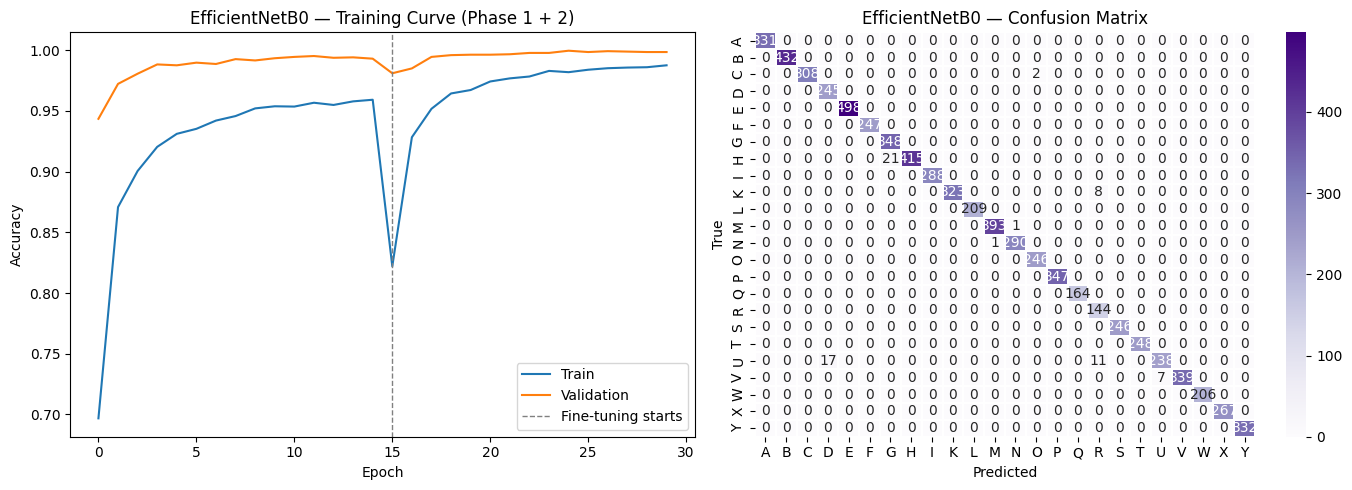


Classification Report (EfficientNetB0):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      0.99      1.00       310
           D       0.94      1.00      0.97       245
           E       1.00      1.00      1.00       498
           F       1.00      1.00      1.00       247
           G       0.94      1.00      0.97       348
           H       1.00      0.95      0.98       436
           I       1.00      1.00      1.00       288
           K       1.00      0.98      0.99       331
           L       1.00      1.00      1.00       209
           M       1.00      1.00      1.00       394
           N       1.00      1.00      1.00       291
           O       0.99      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       0.88      1.00      0

In [50]:
# -----------------------------
# 8.4 EfficientNetB0 — Evaluation
# -----------------------------
eff_preds = np.argmax(eff_model.predict(X_test_eff, verbose=0), axis=1)

# Combined training curve (Phase 1 + Phase 2)
all_acc = history_eff_p1.history['accuracy']     + history_eff_p2.history['accuracy']
all_val = history_eff_p1.history['val_accuracy'] + history_eff_p2.history['val_accuracy']
split   = len(history_eff_p1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(all_acc, label='Train')
axes[0].plot(all_val, label='Validation')
axes[0].axvline(split, color='gray', linestyle='--', linewidth=1, label='Fine-tuning starts')
axes[0].set_title('EfficientNetB0 — Training Curve (Phase 1 + 2)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

cm_eff = confusion_matrix(y_true, eff_preds)
sns.heatmap(cm_eff, ax=axes[1], annot=True, fmt='d', linewidth=0.2,
            xticklabels=letters, yticklabels=letters, cmap='Purples')
axes[1].set_title('EfficientNetB0 — Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

print('\nClassification Report (EfficientNetB0):')
print(classification_report(y_true, eff_preds, target_names=letters))

In [51]:
# -----------------------------
# 9.1 Accuracy Comparison Table
# -----------------------------
comparison = pd.DataFrame([
    {'Model': 'Random Forest',   'Accuracy': rf_acc,        'Type': 'Classical ML'},
    {'Model': 'SVM (RBF)',        'Accuracy': svm_acc,       'Type': 'Classical ML'},
    {'Model': 'Custom CNN',       'Accuracy': best_cnn_acc,  'Type': 'Deep Learning'},
    {'Model': 'ResNet-style',     'Accuracy': resnet_acc,    'Type': 'Deep Learning'},
    {'Model': 'EfficientNetB0',   'Accuracy': eff_acc,       'Type': 'Transfer Learning'},
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

comparison['Accuracy %'] = (comparison['Accuracy'] * 100).round(2)
print(comparison[['Model', 'Type', 'Accuracy %']].to_string(index=False))

         Model              Type  Accuracy %
  ResNet-style     Deep Learning      100.00
EfficientNetB0 Transfer Learning       99.05
    Custom CNN     Deep Learning       94.31
     SVM (RBF)      Classical ML       83.71
 Random Forest      Classical ML       82.11


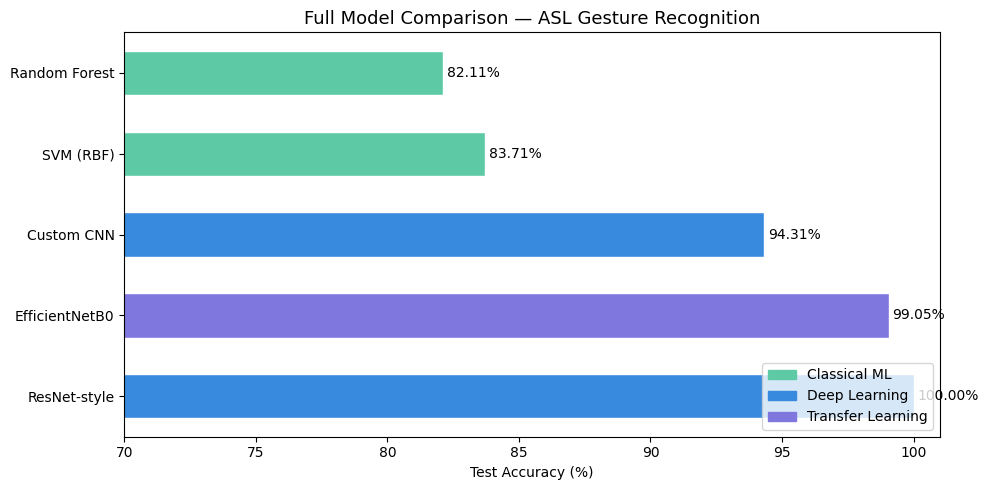

In [52]:
# -----------------------------
# 9.2 Comparison Bar Chart
# -----------------------------
color_map = {
    'Classical ML':      '#5DCAA5',
    'Deep Learning':     '#378ADD',
    'Transfer Learning': '#7F77DD'
}
colors = [color_map[t] for t in comparison['Type']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(comparison['Model'], comparison['Accuracy %'], color=colors, edgecolor='white', height=0.55)
ax.set_xlabel('Test Accuracy (%)')
ax.set_title('Full Model Comparison — ASL Gesture Recognition', fontsize=13)
ax.set_xlim(70, 101)
for bar, val in zip(bars, comparison['Accuracy %']):
    ax.text(val + 0.15, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center', fontsize=10)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
ax.legend(handles=legend_patches, loc='lower right')
plt.tight_layout()
plt.show()

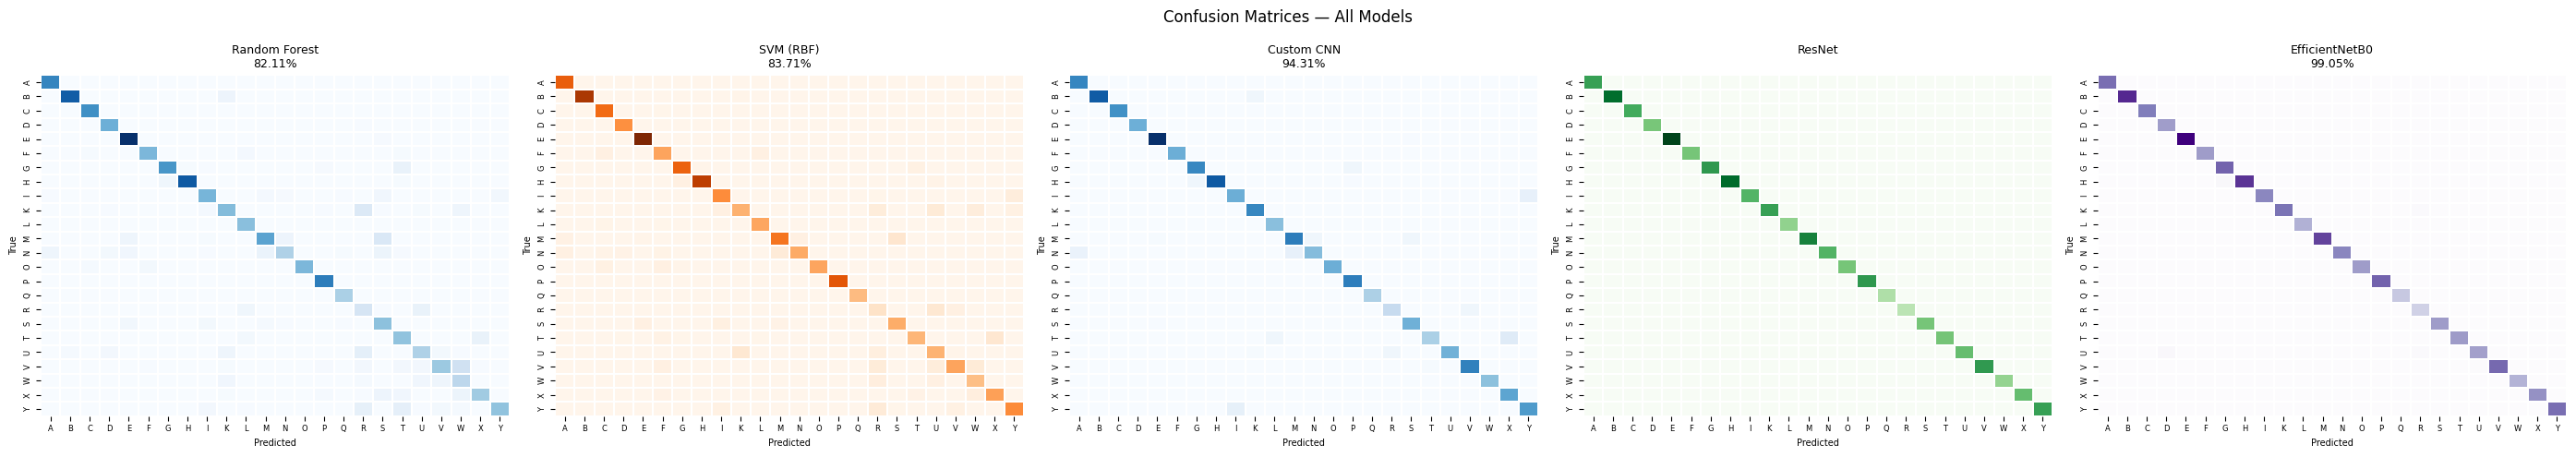

In [53]:
# -----------------------------
# 9.3 Side-by-Side Confusion Matrices (all 5 models)
# -----------------------------
all_cms    = [cm_rf,    cm_svm,    cm_cnn,         cm_resnet,    cm_eff]
all_titles = ['Random Forest', 'SVM (RBF)', 'Custom CNN', 'ResNet', 'EfficientNetB0']
all_cmaps  = ['Blues', 'Oranges', 'Blues', 'Greens', 'Purples']

fig, axes = plt.subplots(1, 5, figsize=(28, 5))
for ax, cm, title, cmap in zip(axes, all_cms, all_titles, all_cmaps):
    sns.heatmap(cm, ax=ax, fmt='d', linewidth=0.1, cmap=cmap,
                xticklabels=letters, yticklabels=letters, cbar=False, annot=False)
    acc_val = comparison.loc[comparison['Model'] == title, 'Accuracy %'].values
    label = f'{acc_val[0]:.2f}%' if len(acc_val) else ''
    ax.set_title(f'{title}\n{label}', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=7)
    ax.set_ylabel('True', fontsize=7)
    ax.tick_params(labelsize=6)

plt.suptitle('Confusion Matrices — All Models', fontsize=12)
plt.tight_layout()
plt.show()

Word Builder

In [ ]:
# -----------------------------
# 10.1 Prediction Functions
# Uses the best-performing model (EfficientNetB0)
# Change `active_model` and `active_input` to switch models
# -----------------------------

def predict_letter_cnn(image_28x28x1):
    """Predict using Custom CNN or ResNet (28x28x1 input)"""
    img = image_28x28x1.reshape(1, 28, 28, 1)
    pred = resnet_model.predict(img, verbose=0)   
    return letters[np.argmax(pred)]

def predict_letter_eff(image_28x28x1):
    """Predict using EfficientNetB0 (resizes internally)"""
    img_eff = preprocess_for_efficientnet(image_28x28x1.reshape(1, 28, 28, 1))
    pred    = eff_model.predict(img_eff, verbose=0)
    return letters[np.argmax(pred)]

# Set active predictor
active_predict = predict_letter_cnn

print('Predictor ready. Using EfficientNetB0.')

Predictor ready. Using EfficientNetB0.


Word reset.


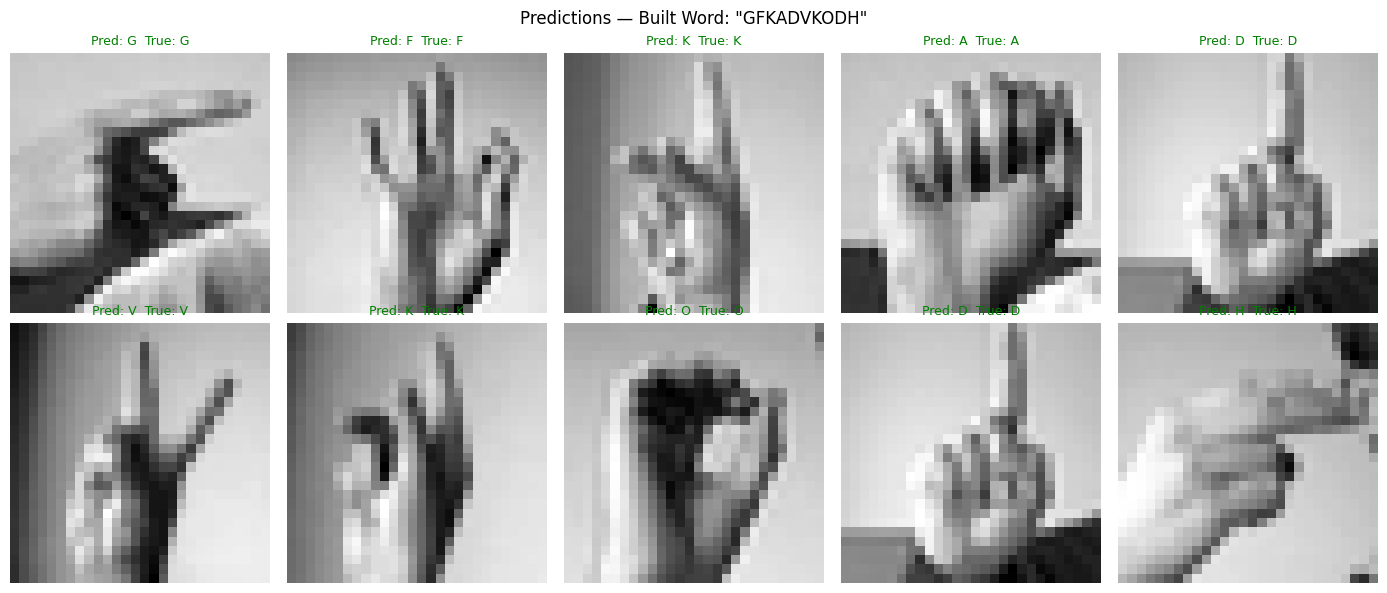

Built word: "GFKADVKODH"


In [61]:
# -----------------------------
# 10.2 Word Builder
# -----------------------------
current_word = ''
last_letter  = None

def update_word(letter):
    global current_word, last_letter
    if letter != last_letter:
        current_word += letter
        last_letter   = letter

def reset_word():
    global current_word, last_letter
    current_word = ''
    last_letter  = None
    print('Word reset.')

# Run predictions on first 10 test images
reset_word()
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i in range(10):
    image  = X_test[i]
    letter = active_predict(image)
    update_word(letter)

    true_letter = letters[y_true[i]]
    axes[i].imshow(image.reshape(28, 28), cmap='gray')
    color = 'green' if letter == true_letter else 'red'
    axes[i].set_title(f'Pred: {letter}  True: {true_letter}', color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle(f'Predictions — Built Word: "{current_word}"', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Built word: "{current_word}"')

In [62]:
# -----------------------------
# 10.3 Text-to-Speech Output
# -----------------------------
try:
    import pyttsx3
    engine = pyttsx3.init()
    engine.setProperty('rate', 150)

    def speak(text):
        print(f'Speaking: "{text}"')
        engine.say(text)
        engine.runAndWait()

    speak(current_word)

except Exception as e:
    print(f'TTS unavailable: {e}')
    print(f'Word to speak: "{current_word}"')

Speaking: "GFKADVKODH"
